In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
X_train = pd.read_csv(r'C:\Users\saima\Desktop\M-Tech\MTech sem 2\DL\Assignments\Assignment 1\DataSets\task2\train_data.csv').values
y_train = pd.read_csv(r'C:\Users\saima\Desktop\M-Tech\MTech sem 2\DL\Assignments\Assignment 1\DataSets\task2\train_label.csv').values.squeeze()
X_test = pd.read_csv(r'C:\Users\saima\Desktop\M-Tech\MTech sem 2\DL\Assignments\Assignment 1\DataSets\task2\test_data.csv').values
y_test = pd.read_csv(r'C:\Users\saima\Desktop\M-Tech\MTech sem 2\DL\Assignments\Assignment 1\DataSets\task2\test_label.csv').values.squeeze()

def one_hot(y, num_classes):
    y = y.astype(int).reshape(-1)
    oh = np.zeros((y.shape[0], num_classes))
    oh[np.arange(y.shape[0]), y] = 1
    return oh

y_train = y_train.astype(int).reshape(-1)
y_test = y_test.astype(int).reshape(-1)
num_classes =len(np.unique(y_train))
Y_train = one_hot(y_train, num_classes)

In [17]:
#Z = [[1, 2, 3],
#     [4, 5, 6]]

#Layer Normalization
#New row = [(1-2), (2-2), (3-2)] = [-1, 0, 1]
#New row = [-1, 0, 1]

#Batch Normalization
#[1,4]
#[2,5]
#[3,6]

def normalize(Z, mode="none", eps=1e-5):
    if mode == "layer":
        mu = np.mean(Z, axis=1, keepdims=True)
        var = np.var(Z, axis=1, keepdims=True)

    elif mode == "batch":
        mu = np.mean(Z, axis=0, keepdims=True)
        var = np.var(Z, axis=0, keepdims=True)

    else:
        return Z

    Z_norm = (Z - mu) / np.sqrt(var + eps)
    return Z_norm

In [18]:
def tanh(Z):
    return np.tanh(Z)

def softmax(Z):
    if Z.ndim == 1:
        Z = Z.reshape(1, -1)
    expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return expZ / np.sum(expZ, axis=1, keepdims=True)

In [19]:
def cross_entropy(Y, Y_hat):
    eps = 1e-9
    loss = -np.sum(Y * np.log(Y_hat + eps)) / Y.shape[0]
    return loss

In [20]:
def forward_normal(X, params, norm_type="none"):

    # Input
    A0 = X

    # -------- Layer 1 --------
    Z1 = np.dot(A0, params["W1"]) + params["b1"]
    Z1 = normalize(Z1, norm_type)
    A1 = tanh(Z1)

    # -------- Layer 2 --------
    Z2 = np.dot(A1, params["W2"]) + params["b2"]
    Z2 = normalize(Z2, norm_type)
    A2 = tanh(Z2)

    # -------- Output Layer --------
    Z3 = np.dot(A2, params["W3"]) + params["b3"]
    A3 = softmax(Z3)

    # Store values (same as cache)
    cache = {
        "A": [A0, A1, A2, A3],
        "Z": [Z1, Z2, Z3]
    }

    return A3, cache

In [28]:
def backward_normal(params, cache, Y):

    grads = {}
    A = cache["A"]   # [A0, A1, A2, A3]
    Z = cache["Z"]   # [Z1, Z2, Z3]
    m = Y.shape[0]

    # -------- Output Layer (Layer 3) --------
    dZ3 = A[3] - Y
    grads["W3"] = np.dot(A[2].T, dZ3) / m
    grads["b3"] = np.sum(dZ3, axis=0, keepdims=True) / m

    # -------- Layer 2 --------
    dA2 = np.dot(dZ3, params["W3"].T)
    dZ2 = dA2 * (1 - A[2]**2)   # derivative of tanh
    grads["W2"] = np.dot(A[1].T, dZ2) / m
    grads["b2"] = np.sum(dZ2, axis=0, keepdims=True) / m

    # -------- Layer 1 --------
    dA1 = np.dot(dZ2, params["W2"].T)
    dZ1 = dA1 * (1 - A[1]**2)   # derivative of tanh
    grads["W1"] = np.dot(A[0].T, dZ1) / m
    grads["b1"] = np.sum(dZ1, axis=0, keepdims=True) / m

    return grads

In [29]:
def adam_init(params):
    m, v = {}, {}
    for k in params:
        m[k] = np.zeros_like(params[k])
        v[k] = np.zeros_like(params[k])
    return m, v

def adam_update(params, grads, m, v, t, lr, beta1=0.9, beta2=0.999, eps=1e-8):

    for k in params.keys():
        m[k] = beta1 * m[k] + (1 - beta1) * grads[k]
        v[k] = beta2 * v[k] + (1 - beta2) * (grads[k] ** 2)

        # Bias correction
        m_hat = m[k] / (1 - beta1 ** t)
        v_hat = v[k] / (1 - beta2 ** t)

        # Update parameters
        params[k] = params[k] - lr * m_hat / (np.sqrt(v_hat) + eps)

    return params

In [30]:
def predict(X, params, norm_type=None):
    Y_hat, _ = forward(X, params, norm_type)
    return np.argmax(Y_hat, axis=1)

def confusion_matrix(y_true, y_pred, num_classes):
    y_true = y_true.astype(int).reshape(-1)
    y_pred = y_pred.astype(int).reshape(-1)
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

In [31]:
def plot_confusion_matrices(cm_train, cm_test, title):

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    matrices = [cm_train, cm_test]
    subtitles = ["Train", "Test"]

    for ax, cm, sub in zip(axes, matrices, subtitles):

        im = ax.imshow(cm)
        fig.colorbar(im, ax=ax)

        ax.set_title(f"{title} - {sub}")
        ax.set_xlabel("Predicted Class")
        ax.set_ylabel("True Class")

        num_classes = cm.shape[0]
        ax.set_xticks(range(num_classes))
        ax.set_yticks(range(num_classes))

        for i in range(num_classes):
            for j in range(num_classes):
                ax.text(j, i, cm[i, j],
                        ha="center", va="center",
                        color="white" if cm[i, j] > cm.max() / 2 else "black")

    plt.tight_layout()
    plt.show()

In [32]:
lr = 0.001
batch_size = 64
threshold = 1e-4
max_epochs = 200
hidden1, hidden2 = 20, 10

np.random.seed(42)
params_init = {
    'W1': np.random.randn(X_train.shape[1], hidden1) * 0.01,
    'b1': np.zeros(hidden1),
    'W2': np.random.randn(hidden1, hidden2) * 0.01,
    'b2': np.zeros(hidden2),
    'W3': np.random.randn(hidden2, num_classes) * 0.01,
    'b3': np.zeros(num_classes)
}


===== No Normalization =====
Converged at epoch 64


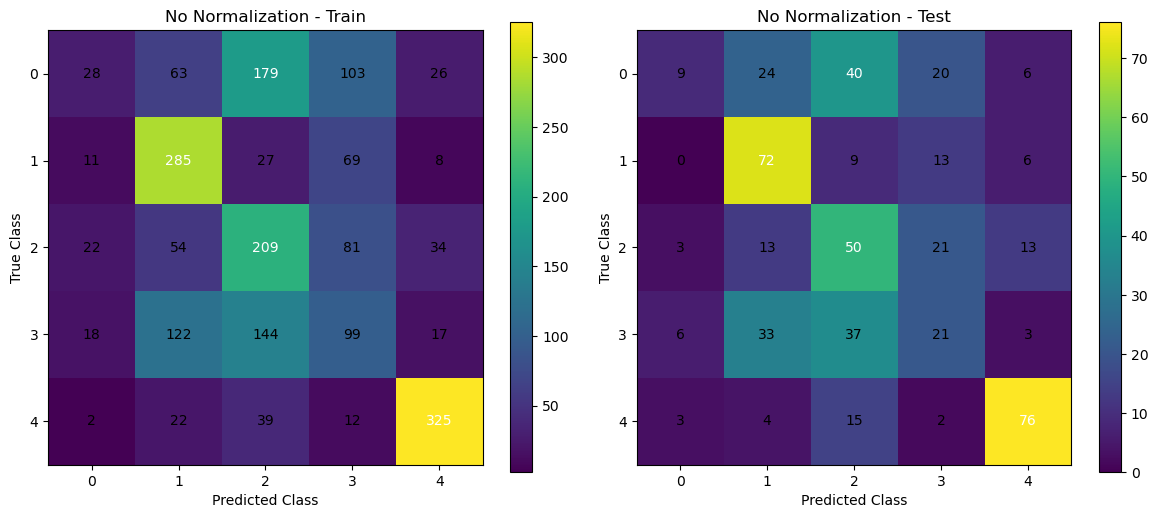


===== Layer Normalization =====
Converged at epoch 32


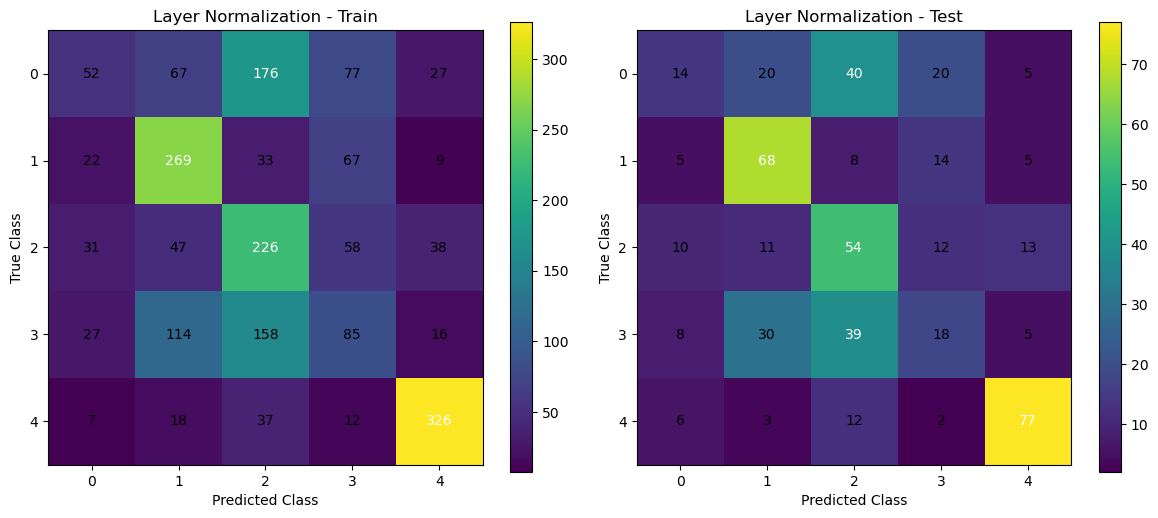


===== Batch Normalization =====
Converged at epoch 88


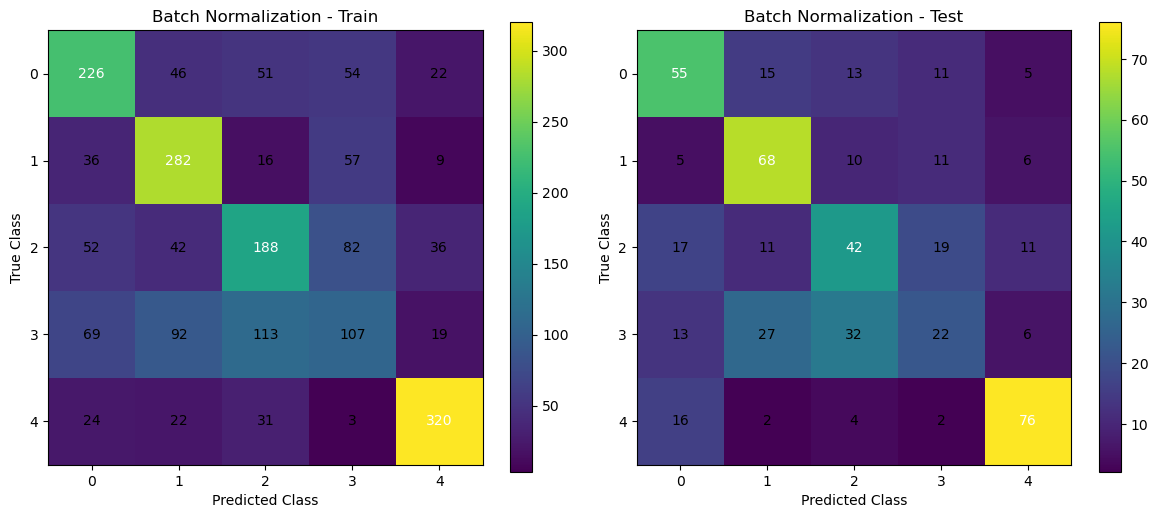

In [33]:
all_loss_hist = {}
epoch_report = {}

norm_methods = {
    "No Normalization": None,
    "Layer Normalization": "layer",
    "Batch Normalization": "batch"
}

N = X_train.shape[0]

for name, norm in norm_methods.items():

    print(f"\n===== {name} =====")

    # Reset parameters
    params = {}
    for k in params_init:
        params[k] = params_init[k].copy()
    m, v = adam_init(params)

    loss_hist = []
    t = 1

    for epoch in range(max_epochs):

        # Shuffle data
        perm = np.random.permutation(N)
        Xs = X_train[perm]
        Ys = Y_train[perm]

        # Mini-batch training
        for i in range(0, N, batch_size):

            Xb = Xs[i:i + batch_size]
            Yb = Ys[i:i + batch_size]

            Y_hat, cache = forward(Xb, params, norm)
            grads = backward(params, cache, Yb)

            params = adam_update(params, grads, m, v, t, lr)
            t += 1

        # Compute full training loss
        Y_hat_full, _ = forward(X_train, params, norm)
        loss = cross_entropy(Y_train, Y_hat_full)
        loss_hist.append(loss)

        # Convergence check
        if epoch > 0 and abs(loss_hist[-1] - loss_hist[-2]) < threshold:
            print(f"Converged at epoch {epoch}")
            epoch_report[name] = epoch
            break

    all_loss_hist[name] = loss_hist

    # ----- Evaluation -----
    train_pred = predict(X_train, params, norm)
    test_pred  = predict(X_test, params, norm)

    cm_train = confusion_matrix(y_train, train_pred, num_classes)
    cm_test  = confusion_matrix(y_test, test_pred, num_classes)

    plot_confusion_matrices(cm_train,cm_test,name)

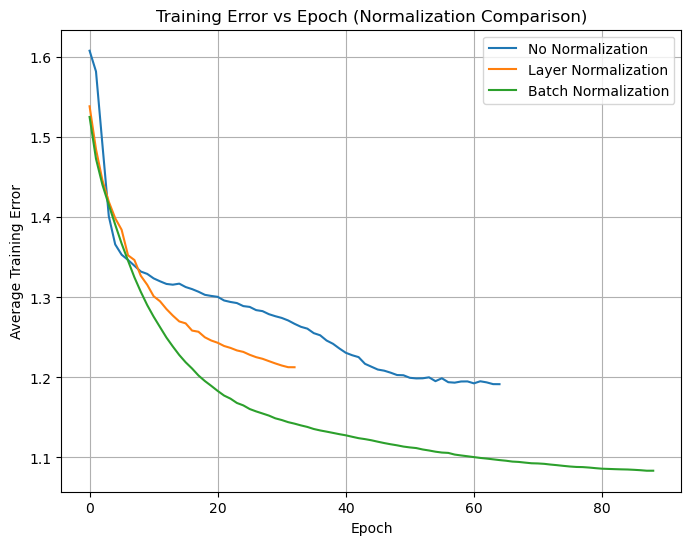

In [34]:
plt.figure(figsize=(8, 6))

for name, loss_hist in all_loss_hist.items():
    plt.plot(loss_hist, label=name)

plt.xlabel("Epoch")
plt.ylabel("Average Training Error")
plt.title("Training Error vs Epoch (Normalization Comparison)")
plt.legend()
plt.grid(True)
plt.show()

In [35]:
print("Epochs to Convergence:")
for method, ep in epoch_report.items():
    print(f"{method}: {ep}")

Epochs to Convergence:
No Normalization: 64
Layer Normalization: 32
Batch Normalization: 88
